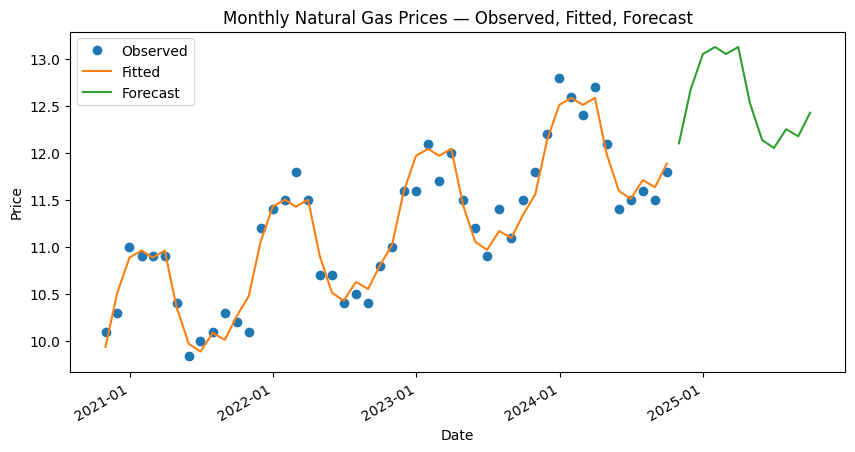

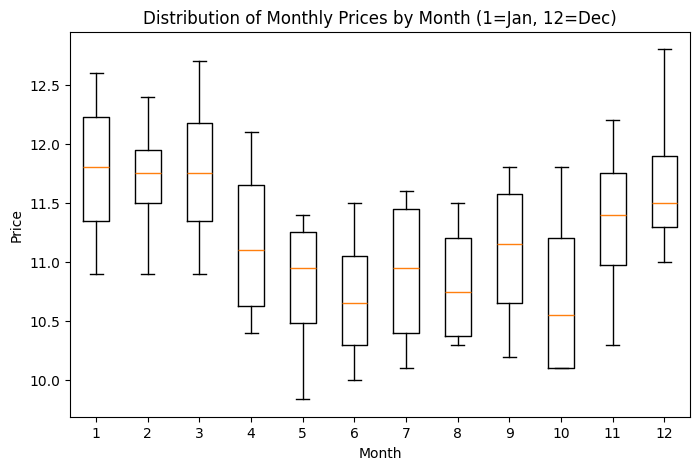

Example price estimates:
2021-02-15: 10.90
2022-08-10: 10.61
2024-09-30: 11.89
2025-06-01: 12.13


In [6]:
# Natural Gas Storage Price Estimation and Extrapolation
# ------------------------------------------------------
# Quantitative Research Task
# ------------------------------------------------------
# Requirements:
# 1. Load monthly natural gas prices (Oct 2020 – Sep 2024)
# 2. Fit a model to analyze and forecast seasonal patterns
# 3. Extrapolate prices for one additional year
# 4. Estimate price for any given date
# 5. Visualize results

# ------------------------------------------------------
# Import libraries
# ------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from datetime import datetime

# ------------------------------------------------------
# Load data
# ------------------------------------------------------
df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')
df = df.sort_values('Dates').reset_index(drop=True)
df['Prices'] = pd.to_numeric(df['Prices'], errors='coerce')
df = df.dropna(subset=['Prices'])

# Monthly time series
ts_monthly = df.set_index('Dates')['Prices'].asfreq('ME')
ts_monthly.index.name = 'Date'

# ------------------------------------------------------
# Fit Holt-Winters Seasonal Model
# ------------------------------------------------------
hw_model = ExponentialSmoothing(ts_monthly, trend='add', seasonal='add', seasonal_periods=12)
hw_fit = hw_model.fit(optimized=True)

# ------------------------------------------------------
# Forecast for next 12 months
# ------------------------------------------------------
forecast_steps = 12
forecast_index = pd.date_range(ts_monthly.index.max() + pd.offsets.MonthEnd(1), periods=forecast_steps, freq='ME')
forecast = hw_fit.forecast(forecast_steps)
forecast = pd.Series(forecast.values, index=forecast_index)

# ------------------------------------------------------
# Combine observed, fitted, and forecast data
# ------------------------------------------------------
fitted = hw_fit.fittedvalues
combined = pd.concat([
    ts_monthly.rename('Observed'),
    fitted.rename('Fitted'),
    forecast.rename('Forecast')
], axis=1)

# ------------------------------------------------------
# Interpolate to daily frequency
# ------------------------------------------------------
monthly_series = fitted.copy()
monthly_series = pd.concat([monthly_series, forecast])
daily_series = monthly_series.reindex(pd.date_range(monthly_series.index.min(), monthly_series.index.max(), freq='D'))
daily_series = daily_series.interpolate(method='cubic')

# ------------------------------------------------------
# Function to estimate price at any given date
# ------------------------------------------------------
def estimate_price(date_input):
    if isinstance(date_input, str):
        dt = pd.to_datetime(date_input)
    elif isinstance(date_input, (pd.Timestamp, datetime)):
        dt = pd.to_datetime(date_input)
    else:
        raise ValueError("date_input must be string or datetime")
    
    min_date, max_date = daily_series.index.min(), daily_series.index.max()
    if dt < min_date or dt > max_date:
        raise ValueError(f"Date {dt.date()} is outside supported range ({min_date.date()} to {max_date.date()})")
    
    return float(daily_series.loc[dt])

# ------------------------------------------------------
# Visualization 1: Observed, Fitted, and Forecast Prices
# ------------------------------------------------------
plt.figure(figsize=(10,5))
plt.plot(ts_monthly.index, ts_monthly.values, 'o', label='Observed')
plt.plot(fitted.index, fitted.values, label='Fitted')
plt.plot(forecast.index, forecast.values, label='Forecast')
plt.title('Monthly Natural Gas Prices — Observed, Fitted, Forecast')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gcf().autofmt_xdate()
plt.show()

# ------------------------------------------------------
# Visualization 2: Seasonal Trend by Month
# ------------------------------------------------------
monthly_df = ts_monthly.copy().to_frame('Price')
monthly_df['Month'] = monthly_df.index.month
plt.figure(figsize=(8,5))
plt.boxplot([monthly_df[monthly_df['Month']==m]['Price'].values for m in range(1,13)],
            labels=[str(m) for m in range(1,13)])
plt.title('Distribution of Monthly Prices by Month (1=Jan, 12=Dec)')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show()

# ------------------------------------------------------
# Example usage
# ------------------------------------------------------
print("Example price estimates:")
for d in ['2021-02-15', '2022-08-10', '2024-09-30', '2025-06-01']:
    print(f"{d}: {estimate_price(d):.2f}")
